<a href="https://colab.research.google.com/github/AncaraniJuanDiego/IAModelosDeRegresi-n./blob/main/TP_IA_(IRIS_DF).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

In [ ]:
iris = load_iris(as_frame = True)
df = iris.frame.copy()

Dataframe que trata sobre especies de iris (genero de +300 tipos de plantas con flores), conocidas por sus vistosas flores de jardin y distribución el en hemisferio norte.

*  Largo_sépalo(cm)
*  Ancho_sétalo(cm)
*  Largo_pétalo(cm)
*  ancho_petalo(cm)
*  Tipo de especie (target)

In [ ]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [ ]:
print('features originales: ', iris.feature_names)
print('Distribución de especies: ')
print(df['target'].value_counts())
print('Distribución estadistica de las features: ')
print(df[['sepal length (cm)', 'sepal width (cm)',
      'petal length (cm)', 'petal width (cm)']].describe())

features originales:  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Distribución de especies: 
target
0    50
1    50
2    50
Name: count, dtype: int64
Distribución estadistica de las features: 
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  


Parte 1: creación de features de area.

target
0    1.462
1    4.260
2    5.552
Name: petal length (cm), dtype: float64


,sepal area
0,17.85
1,14.70
2,15.04
3,14.26
4,18.00


,petal area
0,0.28
1,0.28
2,0.26
3,0.30
4,0.28


,total_area
0,18.13
1,14.98
2,15.30
3,14.56
4,18.28


Media de area del sepalo, agrupada x especie: 
target
0    17.2578
1    16.5262
2    19.6846
Name: sepal area, dtype: float64


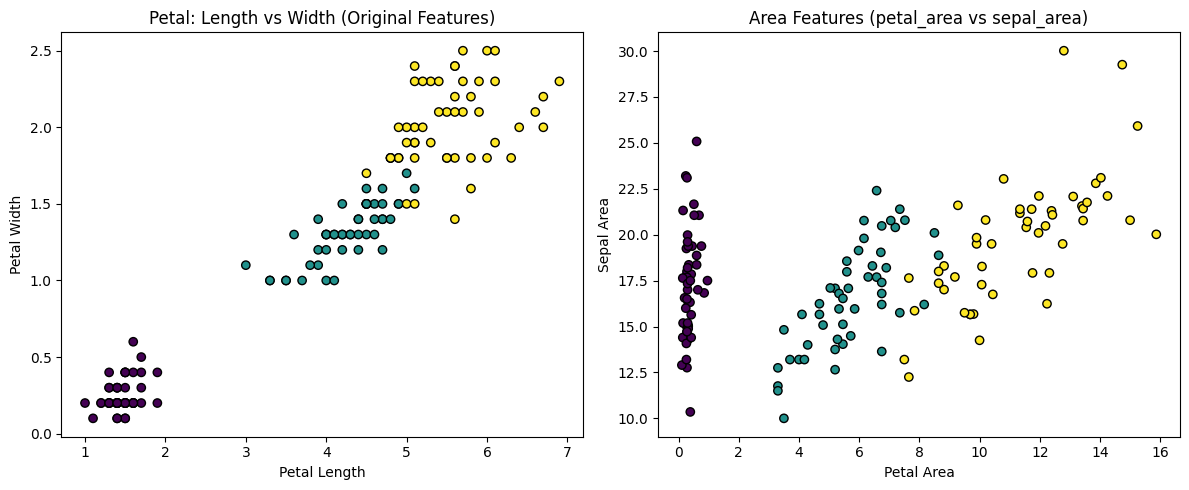

In [ ]:
#area → largo * ancho

#1.1 agrupar x tipo de especie, la media de 'largo de pétalo'.
print(df.groupby('target')['petal length (cm)'].mean())

#1.2 Crear feature 'sepal_area' como producto de sus variables.

df['sepal area'] = df['sepal length (cm)'] * df['sepal width (cm)']
display(df['sepal area'].head(5))

df['petal area'] = df['petal length (cm)'] * df['petal width (cm)']
display(df['petal area'].head())

#1.3 crear 'total_area' con la suma de ambos

df['total_area'] = df['sepal area'] + df['petal area']
display(df['total_area'].head())

#1.4 calcular media de petal_area x especie

print('Media de area del sepalo, agrupada x especie: ')
print(df.groupby('target')['sepal area'].mean())


# 1.5 Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico izquierdo: pétalo (features originales)
scatter0 = axes[0].scatter(
    df['petal length (cm)'],
    df['petal width (cm)'],
    c=df['target'], cmap='viridis', edgecolors='k'
)
axes[0].set_xlabel('Petal Length')
axes[0].set_ylabel('Petal Width')
axes[0].set_title('Petal: Length vs Width (Original Features)')


# Gráfico derecho: features de área
scatter1 = axes[1].scatter(
    df['petal area'],
    df['sepal area'],
    c=df['target'], cmap='viridis', edgecolors='k'
)
axes[1].set_xlabel('Petal Area')
axes[1].set_ylabel('Sepal Area')
axes[1].set_title('Area Features (petal_area vs sepal_area)')


plt.tight_layout()
plt.savefig('comparacion_areas.png', dpi=150)
plt.show()

Comporativa:

* En morado → tipo 0.
* En verdeAgua → tipo 1.
* En amarillo → tipo 2.

**Grafico 1 (ancho de petalo).**


Las iris tipo 0, son las que tienen menor area de petalo. Con distribuciones realmente bajas, 1-2 en largo y 0-0.5 en ancho.

Las tipo 1, tienen tamaño moderado de area de patalo, incluso se mezclan las que tienen mayor tamaño con las tipo 2, que adquieren mayor area que las anteriores, 6-7 de largo y 2-2.5 de ancho.


**Grafico 2 (features agregadas - area de pétalo vs area de sépalo).**

Las tipo o son muy pequeñas en base a el ancho del pétalo, ya que se mantienen en una barrera de 0.5 - 1. Pero tienen gran tamaño en el area del sépalo, debido a que son muy longevas y anchas.

La clave es entender que las tipo 0 son las menores en el area de pétalo, y en el area de sépalo tienen una parecida distribución.

In [ ]:
#Parte 2. Ratio dimensional y transformaciones avanzadas.

#ratio → length / width

df['petal_aspect_ratio'] = df['petal length (cm)'] / df['petal width (cm)']
print('Radio de pétalos:')
display(df['petal_aspect_ratio'].head())

df['sepal_aspect_ratio'] = df['sepal length (cm)'] / df['sepal width (cm)']
print('Radio de sépalos:')
display(df['sepal_aspect_ratio'].head())

#2.2 'petal_sepal_length_ratio'

df['petal_sepal_length_ratio'] = df['petal length (cm)'] / df['sepal length (cm)']
print('Radio longevo (Petal Length / Sepal Length):')
display(df['petal_sepal_length_ratio'].head())

#2.2.1 'sepal_width_to_length_ratio'
df['sepal_width_to_length_ratio'] = df['sepal width (cm)'] / df['sepal length (cm)']
print('Radio entre ancho y largo de sépalos:')
display(df['sepal_width_to_length_ratio'].head())

#Analisis de discriminación (calcular std y mean) en 'petal_aspect_ratio' x especie

print('\nAnálisis discriminativo de petal_aspect_ratio por especie:')
print(df.groupby('target')['petal_aspect_ratio'].agg(['mean', 'std']))

#¿Qué especie tiene el pétalo más "alargado" (mayor ratio)?
especie_mas_alargada = df.groupby('target')['petal_aspect_ratio'].mean().idxmax()
print(f"\nEspecie con pétalo más alargado: {especie_mas_alargada}")


Radio de pétalos:


,petal_aspect_ratio
0,7.0
1,7.0
2,6.5
3,7.5
4,7.0


Radio de sépalos:


,sepal_aspect_ratio
0,1.457143
1,1.633333
2,1.468750
3,1.483871
4,1.388889


Radio longevo (Petal Length / Sepal Length):


,petal_sepal_length_ratio
0,0.274510
1,0.285714
2,0.276596
3,0.326087
4,0.280000


Radio entre ancho y largo de sépalos:


,sepal_width_to_length_ratio
0,0.686275
1,0.612245
2,0.680851
3,0.673913
4,0.720000



Análisis discriminativo de petal_aspect_ratio por especie:
            mean       std
target                    
0       6.908000  2.854545
1       3.242837  0.312456
2       2.780662  0.407367

Especie con pétalo más alargado: 0


In [ ]:
#Observar df con features nuevas..
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,sepal area,petal area,total_area,petal_aspect_ratio,sepal_aspect_ratio,petal_sepal_length_ratio,sepal_width_to_length_ratio
0,5.1,3.5,1.4,0.2,0,17.85,0.28,18.13,7.000000,1.457143,0.274510,0.686275
1,4.9,3.0,1.4,0.2,0,14.70,0.28,14.98,7.000000,1.633333,0.285714,0.612245
2,4.7,3.2,1.3,0.2,0,15.04,0.26,15.30,6.500000,1.468750,0.276596,0.680851
3,4.6,3.1,1.5,0.2,0,14.26,0.30,14.56,7.500000,1.483871,0.326087,0.673913
4,5.0,3.6,1.4,0.2,0,18.00,0.28,18.28,7.000000,1.388889,0.280000,0.720000
...,...,...,...,...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,20.10,11.96,32.06,2.260870,2.233333,0.776119,0.447761
146,6.3,2.5,5.0,1.9,2,15.75,9.50,25.25,2.631579,2.520000,0.793651,0.396825
147,6.5,3.0,5.2,2.0,2,19.50,10.40,29.90,2.600000,2.166667,0.800000,0.461538
148,6.2,3.4,5.4,2.3,2,21.08,12.42,33.50,2.347826,1.823529,0.870968,0.548387


Parte 2.3 → transformaciones matematicas

largo de pétalo al cuadrado


,petal length **2
0,1.96
1,1.96
2,1.69
3,2.25
4,1.96
...,...
145,27.04
146,25.00
147,27.04
148,29.16


producto entre largo de sépalo y largo de pétalo


,sepal_petal_length_product
0,7.14
1,6.86
2,6.11
3,6.90
4,7.00
...,...
145,34.84
146,31.50
147,33.80
148,33.48


diferencia entre largo de sépalo y largo de pétalo


,sepal_petal_length_difference
0,3.7
1,3.5
2,3.4
3,3.1
4,3.6
...,...
145,1.5
146,1.3
147,1.3
148,0.8


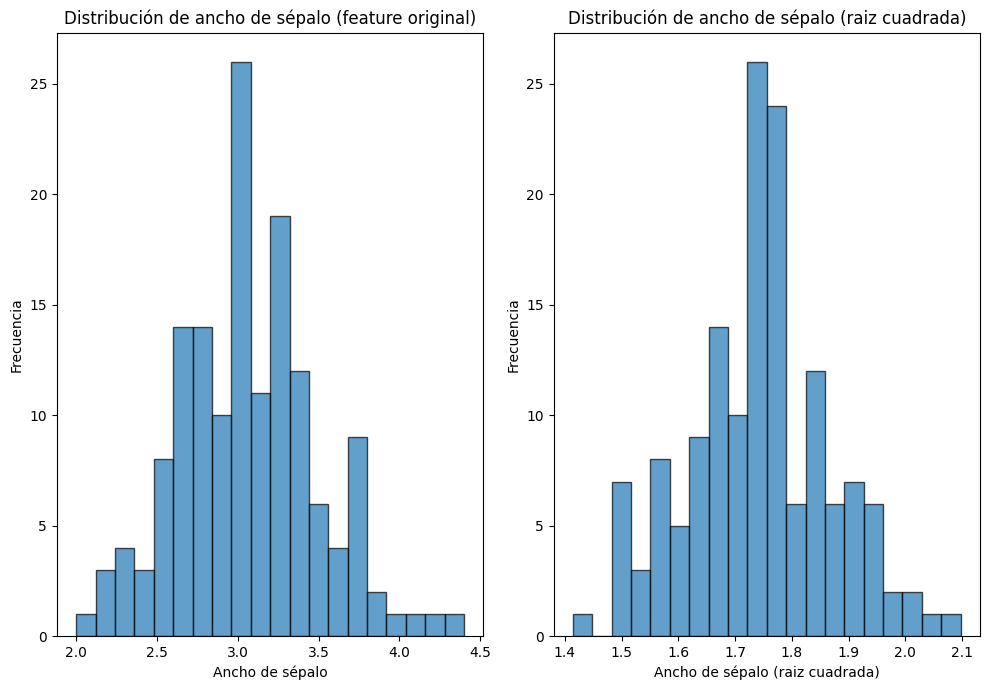

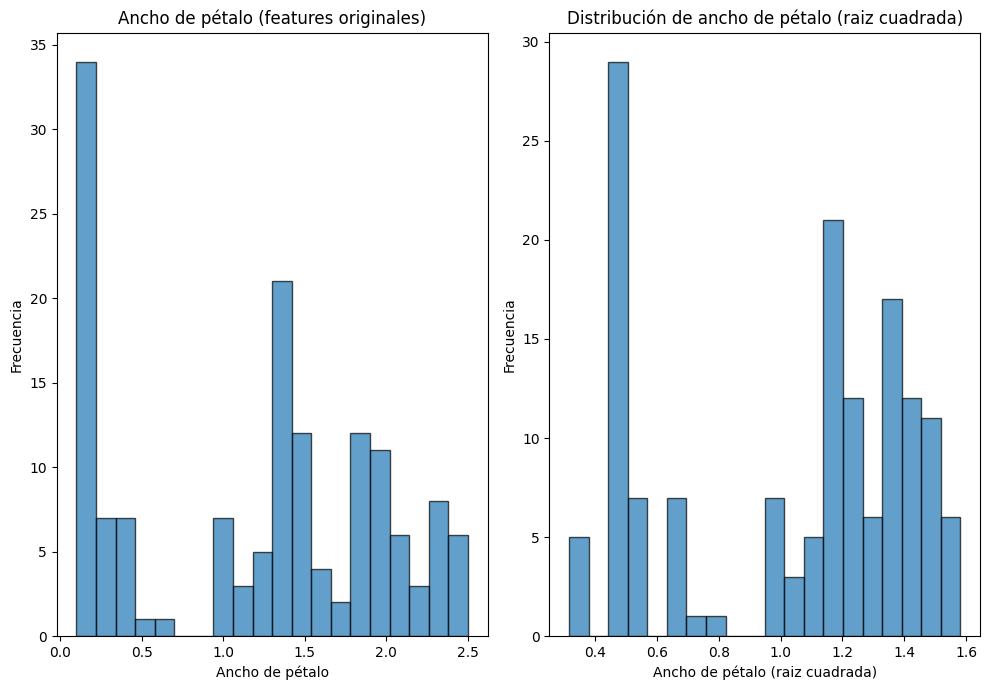

In [ ]:
#2.3: Crear 'petal_length_squared' (feature_polimonial)

#longitud de pétalo al cuadrado : length ** 2.

df['petal length **2'] = df['petal length (cm)'] ** 2
print('largo de pétalo al cuadrado')
display(df['petal length **2']) # Corrected column name

df['sepal width sqrt'] = np.sqrt(df['sepal width (cm)'])
df['petal width sqrt'] = np.sqrt(df['petal width (cm)'])

#producto entre lengitud.

df['sepal_petal_length_product'] = df['sepal length (cm)'] * df['petal length (cm)']
print('producto entre largo de sépalo y largo de pétalo')
display(df['sepal_petal_length_product'])


#Diferencia entre longitud.
df['sepal_petal_length_difference'] = df['sepal length (cm)'] - df['petal length (cm)']
print('diferencia entre largo de sépalo y largo de pétalo')
display(df['sepal_petal_length_difference'])

#2.3.1: distribución de la transformada

fig_sepal, axes_sepal = plt.subplots(1, 2, figsize=(10, 7)) # Using 1 row, 2 columns

# Original sepal width histogram
axes_sepal[0].hist(df['sepal width (cm)'], bins=20, edgecolor='black', alpha=0.7)
axes_sepal[0].set_title('Distribución de ancho de sépalo (feature original)')
axes_sepal[0].set_xlabel('Ancho de sépalo')
axes_sepal[0].set_ylabel('Frecuencia')

# sepal width histogram
axes_sepal[1].hist(df['sepal width sqrt'], bins=20, edgecolor='black', alpha=0.7)
axes_sepal[1].set_title('Distribución de ancho de sépalo (raiz cuadrada)')
axes_sepal[1].set_xlabel('Ancho de sépalo (raiz cuadrada)')
axes_sepal[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Plotting distributions for Petal Width
fig_petal, axes_petal = plt.subplots(1, 2, figsize=(10, 7)) # Using 1 row, 2 columns

axes_petal[0].hist(df['petal width (cm)'], bins=20, edgecolor='black', alpha=0.7)
axes_petal[0].set_title('Ancho de pétalo (features originales)')
axes_petal[0].set_xlabel('Ancho de pétalo')
axes_petal[0].set_ylabel('Frecuencia')

# Square root of petal width histogram
axes_petal[1].hist(df['petal width sqrt'], bins=20, edgecolor='black', alpha=0.7)
axes_petal[1].set_title('Distribución de ancho de pétalo (raiz cuadrada)')
axes_petal[1].set_xlabel('Ancho de pétalo (raiz cuadrada)')
axes_petal[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('transformacion_sqrt.png', dpi=150)
plt.show()


* Por lo observado la distribución en 'ancho de sépalo' suele tender a ser normal, ya que sube en el centroide y baja en los extremos. Con mayor frecuencia entre 2.5 - 3.5 de anchura. La mayoria de las plantas con +25 tienen 3.0 de ancho.

* En 'ancho de pétalo' no parece haber simetría respecto a las variables.

In [ ]:
#Observar Df con features nuevas...
df


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,sepal area,petal area,total_area,petal_aspect_ratio,sepal_aspect_ratio,petal_sepal_length_ratio,sepal_width_to_length_ratio,petal length **2,sepal width sqrt,petal width sqrt,sepal_petal_length_product,sepal_petal_length_difference
0,5.1,3.5,1.4,0.2,0,17.85,0.28,18.13,7.000000,1.457143,0.274510,0.686275,1.96,1.870829,0.447214,7.14,3.7
1,4.9,3.0,1.4,0.2,0,14.70,0.28,14.98,7.000000,1.633333,0.285714,0.612245,1.96,1.732051,0.447214,6.86,3.5
2,4.7,3.2,1.3,0.2,0,15.04,0.26,15.30,6.500000,1.468750,0.276596,0.680851,1.69,1.788854,0.447214,6.11,3.4
3,4.6,3.1,1.5,0.2,0,14.26,0.30,14.56,7.500000,1.483871,0.326087,0.673913,2.25,1.760682,0.447214,6.90,3.1
4,5.0,3.6,1.4,0.2,0,18.00,0.28,18.28,7.000000,1.388889,0.280000,0.720000,1.96,1.897367,0.447214,7.00,3.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,20.10,11.96,32.06,2.260870,2.233333,0.776119,0.447761,27.04,1.732051,1.516575,34.84,1.5
146,6.3,2.5,5.0,1.9,2,15.75,9.50,25.25,2.631579,2.520000,0.793651,0.396825,25.00,1.581139,1.378405,31.50,1.3
147,6.5,3.0,5.2,2.0,2,19.50,10.40,29.90,2.600000,2.166667,0.800000,0.461538,27.04,1.732051,1.414214,33.80,1.3
148,6.2,3.4,5.4,2.3,2,21.08,12.42,33.50,2.347826,1.823529,0.870968,0.548387,29.16,1.843909,1.516575,33.48,0.8


Parte 3→ impacto y modelado

In [ ]:
from sklearn.feature_selection import f_classif

In [ ]:
#3.1 evaluación de separabilidad
original_features = ['sepal length (cm)', 'sepal width (cm)',
                       'petal length (cm)', 'petal width (cm)']
features_engineered = ['petal area', 'sepal area', 'petal_aspect_ratio',
                       'petal_sepal_length_ratio', 'petal length **2']

X_original = df[original_features]
X_engineered = df[features_engineered]
y = df['target']

In [ ]:
#calcular f_score con features originales..

f_score_orig , p_value_orig = f_classif(X_original, y)

#para nuevas

f_score_eng , p_value_eng = f_classif(X_engineered, y)

#results
print(f' f scores (explain model)- original features: ')
for feat, score in zip(X_original, f_score_orig):
    print(f"  {feat}: {score:.2f}")

print(f' f scores (explain model)- features engineered: ')
for feat, score in zip(X_engineered, f_score_eng):
    print(f"  {feat}: {score:.2f}")

print('------------------------------------')
#Indentificar mejores resultados para cada conjunto..

best_original = original_features[np.argmax(f_score_orig)]
best_engineered = features_engineered[np.argmax(f_score_eng)]

print(f'Best original features for predict: {best_original}')
print(f'Best original features for predict: {best_engineered}')

 f scores (explain model)- original features: 
  sepal length (cm): 119.26
  sepal width (cm): 49.16
  petal length (cm): 1180.16
  petal width (cm): 960.01
 f scores (explain model)- features engineered: 
  petal area: 683.11
  sepal area: 14.24
  petal_aspect_ratio: 91.18
  petal_sepal_length_ratio: 2081.77
  petal length **2: 573.97
------------------------------------
Best original features for predict: petal length (cm)
Best original features for predict: petal_sepal_length_ratio


En caso de querer predécir alguna caracteristica: Los mejores candidatos que mas ayudarian el proceso serían:
*  {'pental length cm': 1180,

    'petal area': 683}

3.2 → divición del modelado

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Dividir datos
X_orig_train, X_orig_test, y_train, y_test = train_test_split(
    X_original, y, test_size=0.3, random_state=42, stratify=y)

X_eng_train, X_eng_test, _, _ = train_test_split(X_engineered, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
#Correlación entre variables

print(df[['sepal length (cm)', 'sepal width (cm)','petal length (cm)', 'petal width (cm)']].corr())

modelo_orig = LogisticRegression(max_iter=200)
modelo_orig.fit(X_orig_train, y_train)
pred_orig = modelo_orig.predict(X_orig_test)
acc_orig = accuracy_score(y_test, pred_orig)

# TODO 3.3.2: Entrenar modelo con features engineered
modelo_eng = LogisticRegression(max_iter=200)
modelo_eng.fit(X_eng_train, y_train)
pred_eng = modelo_eng.predict(X_eng_test)
acc_eng = accuracy_score(y_test, pred_eng)

print(f"\nAccuracy con features originales: {acc_orig:.4f}")
print(f"Accuracy con features engineered: {acc_eng:.4f}")

# TODO 3.3.3: Calcular mejora porcentual
mejora_porcentual = ((acc_eng - acc_orig) / acc_orig) * 100
print(f"Mejora porcentual: {mejora_porcentual:+.2f}%")

# Análisis de errores
print("\nReporte de clasificación (features engineered):")
print(classification_report(y_test, pred_eng,
                           target_names=iris.target_names))


                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  

Accuracy con features originales: 0.9333
Accuracy con features engineered: 0.9333
Mejora porcentual: +0.00%

Reporte de clasificación (features engineered):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.83      1.00      0.91        15
   virginica       1.00      0.80      0.89        15

    accuracy                           0.93     

**Interpretación:**

* Acurracy: predicciones_correctas/ total_predicciones.

→ Las originales y nuevas tienen el mismo resultado, es decir no hay variaciones entre ambas, sin mejoras percentuales. Entonces el modelo se mantiene igual y no cambia nada. Las acurracy altas con cada feature, indican que el modelo se equivoca demasiado poco. (0.93) → en ambas.

* Reporte de clasificación:

→Precision → Que tan confiables son las variables para predecir.

→Racall → Que tan bien detectan las variables al entrenar.

→F1-score → balance entre Precision y Racall

* Resultados:

→ setosa (tipo 0): 100% es facil de clasificar, debido a que esta aislada de las otroas plantas en base al tamaño de pétalos y sépalos.

→ versicolor(tipo 1): 83% empiezan a haber errores de precision y el modelo no puede clasificar perfectamente. Puede que, detecte todas las versicolor, pero a veces confunde otras especies.

→virginica (tipo 2): 100% facil de clasificar, pero cuando predice virginica, acierta pero se le escapan algunas (las confunde con versicolor).